# Sequence-to-Sequence Models: Character-Level English → French Translation

**What this notebook covers:**
- Theory of encoder-decoder architecture for sequence transduction
- Building a character-level seq2seq model **from scratch using NumPy**
- Implementing the same task with **sklearn** as a baseline comparison
- Hyperparameter experiments and interview preparation

**Prerequisites:** NumPy, pandas, matplotlib, seaborn, scikit-learn

**Dataset:** [English-French Sentence Translations on Kaggle](https://www.kaggle.com/datasets/devicharith/language-translation-englishfrench)
**Credits:** Original sentence pairs from [ManyThings.org](http://www.manythings.org/anki/) (Tatoeba project), CC-BY 2.0.


In [28]:
import numpy as np              # Numerical computing, from-scratch models
import pandas as pd             # Data loading and manipulation
import matplotlib.pyplot as plt # Plotting
import seaborn as sns           # Enhanced visualizations
import os, zipfile, urllib.request # File handling and download
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# sklearn components for baseline comparison
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


## Part 1: Theory Recap — Sequence-to-Sequence Models

1. **Encoder-Decoder Architecture:** Two RNNs connected in series; the encoder reads the input sequence into a fixed-length context vector (final hidden state), and the decoder generates the output sequence from that vector.
2. **Teacher Forcing:** During training, the decoder receives the ground-truth output token as the next input instead of its own prediction, which accelerates convergence.
3. **Backpropagation Through Time (BPTT):** Gradients are unfolded backward through every time step of both encoder and decoder; gradient clipping prevents exploding gradients.
4. **Greedy Decoding:** At inference, the decoder picks the highest-probability token at each step and feeds it as the next input; beam search is a more expensive alternative.
5. **No Free Lunch:** Without attention, the encoder compresses the entire input into a single vector — a bottleneck that loses information for long sequences.


### Load and Explore the Dataset

We use the English-French sentence-pair dataset from Kaggle. Each row is a tab-separated pair. We'll inspect structure, check for nulls, and understand the vocabulary.


In [29]:
# --- Download dataset ---
DATA_URL = "https://www.manythings.org/anki/fra-eng.zip"
DATA_DIR = "data"
FRA_TXT_PATH = os.path.join(DATA_DIR, "fra.txt") # Define the target file path

if not os.path.exists(FRA_TXT_PATH): # Check if the actual data file exists
    os.makedirs(DATA_DIR, exist_ok=True) # Ensure data directory exists
    zip_path = os.path.join(DATA_DIR, "fra-eng.zip")
    print("Downloading dataset from ManyThings.org...")

    # Add a User-Agent header to mimic a browser to avoid 406 error
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'
    }
    req = urllib.request.Request(DATA_URL, headers=headers)
    with urllib.request.urlopen(req) as response, \
         open(zip_path, 'wb') as out_file:
             out_file.write(response.read())

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(DATA_DIR)
    os.remove(zip_path)
    print("Done.")

# --- Load pairs ---
with open(os.path.join(DATA_DIR, "fra.txt"), encoding="utf-8") as f:
    lines = f.read().strip().split("\n")
pairs_raw = [line.split("\t")[0:2] for line in lines]  # (english, french)
print(f"Total pairs: {len(pairs_raw)}")

# --- Build DataFrame for inspection ---
df = pd.DataFrame(pairs_raw, columns=["English", "French"])
print(df.head(10))
print("\n--- Info ---")
print(df.info())
print("\n--- Describe ---")
print(df.describe())

print("\nExample English sentence lengths (chars):", [len(s) for s in df["English"].head(10)])
print("Example French sentence lengths (chars):", [len(s) for s in df["French"].head(10)])

Total pairs: 240521
  English                          French
0     Go.                            Va !
1     Go.                         Marche.
2     Go.                      En route !
3     Go.                         Bouge !
4     Hi.                         Salut !
5     Hi.                          Salut.
6    Run!                         Cours !
7    Run!                        Courez !
8    Run!  Prenez vos jambes à vos cous !
9    Run!                          File !

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240521 entries, 0 to 240520
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   English  240521 non-null  object
 1   French   240521 non-null  object
dtypes: object(2)
memory usage: 3.7+ MB
None

--- Describe ---
                                                  English      French
count                                              240521      240521
unique                                 

### Preprocessing Pipeline

Steps:
1. **Filter** sentences by length for tractable training.
2. **Build vocabularies** — map every character in English/French to a unique integer index.
3. **One-hot encode** each character for the from-scratch RNN (no embedding layer — pure NumPy).
4. **Create decoder input/target** — decoder input gets `<SOS>` prepended; decoder target gets `<EOS>` appended.


In [30]:
# --- Filter to short sentences for tractable training ---
MAX_ENC_LEN = 20   # max English characters (including EOS)
MAX_DEC_LEN = 20   # max French characters (including SOS/EOS)
MIN_LEN = 1

pairs = []
for eng, fra in pairs_raw:
    if MIN_LEN <= len(eng) <= MAX_ENC_LEN - 1 and MIN_LEN <= len(fra) <= MAX_DEC_LEN - 2:
        pairs.append((eng.lower(), fra.lower()))

# Use a subset for speed
SUBSET = 2000
pairs = pairs[:SUBSET]
print(f"Using {len(pairs)} sentence pairs after filtering")

# --- Build character vocabularies ---
class Vocabulary:
    def __init__(self):
        self.char2idx = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
        self.idx2char = {0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: '<UNK>'}
        self.size = 4

    def build(self, sentences):
        for s in sentences:
            for c in s:
                if c not in self.char2idx:
                    self.char2idx[c] = self.size
                    self.idx2char[self.size] = c
                    self.size += 1

    def encode(self, sentence, eos=True):
        indices = [self.char2idx.get(c, 3) for c in sentence]
        if eos:
            indices.append(2)
        return indices

    def decode(self, indices):
        chars = []
        for i in indices:
            c = self.idx2char.get(i, '?')
            if c == '<EOS>':
                break
            if c in ('<PAD>', '<SOS>', '<UNK>'):
                if c == '<UNK>':
                    chars.append('?')
                continue
            chars.append(c)
        return ''.join(chars)

    def one_hot(self, idx):
        vec = np.zeros((1, self.size))
        vec[0, idx] = 1.0
        return vec

eng_vocab = Vocabulary()
fra_vocab = Vocabulary()
eng_vocab.build([p[0] for p in pairs])
fra_vocab.build([p[1] for p in pairs])

print(f"English vocab size: {eng_vocab.size}")
print(f"French vocab size: {fra_vocab.size}")
print(f"English chars: {''.join(eng_vocab.idx2char[i] for i in range(4, eng_vocab.size))}")
print(f"French chars: {''.join(fra_vocab.idx2char[i] for i in range(4, fra_vocab.size))}")

# --- Create preprocessed data for from-scratch model ---
enc_data = []
dec_in_data = []
dec_tgt_data = []

for eng, fra in pairs:
    enc_indices = eng_vocab.encode(eng, eos=True)
    enc_onehots = [eng_vocab.one_hot(idx) for idx in enc_indices]
    enc_data.append(enc_onehots)

    fra_indices = fra_vocab.encode(fra, eos=False)
    dec_in_indices = [1] + fra_indices
    dec_in_onehots = [fra_vocab.one_hot(idx) for idx in dec_in_indices]
    dec_in_data.append(dec_in_onehots)

    dec_tgt_indices = fra_indices + [2]
    dec_tgt_data.append(dec_tgt_indices)

print(f"Example encoder input length: {len(enc_data[0])}")
print(f"Example decoder input length: {len(dec_in_data[0])}")
print(f"Example decoder target length: {len(dec_tgt_data[0])}")
print(f"English: '{pairs[0][0]}' -> French: '{pairs[0][1]}'")


Using 2000 sentence pairs after filtering
English vocab size: 44
French vocab size: 59
English chars: go.hirun!w?dckfelpjmstab yxq'19vz,8:30"&
French chars: va !mrche.noutbgslzfiyq?ç w à-'dpêjé’x,è19œâûkôî 830«»&
Example encoder input length: 4
Example decoder input length: 5
Example decoder target length: 5
English: 'go.' -> French: 'va !'


## Part 2: From-Scratch Implementation (NumPy Only)

We implement an **RNN-based encoder-decoder** with:
- A simple RNN cell (no gates, just `tanh`)
- Teacher forcing during training
- Greedy decoding during inference
- Full BPTT with gradient clipping

The class provides the same `fit()` / `predict()` API you'd expect from sklearn, so comparisons are fair.


In [31]:
class Seq2SeqScratch:
    """
    Character-level sequence-to-sequence model using a simple RNN.
    Encoder: reads input chars, produces final hidden state.
    Decoder: generates output chars from encoder state.
    All operations use NumPy only.
    """
    def __init__(self, input_vocab_size, output_vocab_size,
                 hidden_size=64, learning_rate=0.01):
        self.input_vocab_size = input_vocab_size
        self.output_vocab_size = output_vocab_size
        self.hidden_size = hidden_size
        self.lr = learning_rate

        # Xavier (Glorot) initialization for stable gradients
        scale_hh = np.sqrt(2.0 / (hidden_size + hidden_size))
        scale_ih = np.sqrt(2.0 / (input_vocab_size + hidden_size))
        scale_oh = np.sqrt(2.0 / (output_vocab_size + hidden_size))
        scale_out = np.sqrt(2.0 / (hidden_size + output_vocab_size))

        # Encoder parameters
        self.W_ih_enc = np.random.randn(input_vocab_size, hidden_size) * scale_ih
        self.W_hh_enc = np.random.randn(hidden_size, hidden_size) * scale_hh
        self.b_h_enc = np.zeros((1, hidden_size))

        # Decoder parameters (separate weights, not shared with encoder)
        self.W_ih_dec = np.random.randn(output_vocab_size, hidden_size) * scale_oh
        self.W_hh_dec = np.random.randn(hidden_size, hidden_size) * scale_hh
        self.b_h_dec = np.zeros((1, hidden_size))

        # Output projection: hidden -> output logits
        self.W_out = np.random.randn(hidden_size, output_vocab_size) * scale_out
        self.b_out = np.zeros((1, output_vocab_size))

    # ----- Activation helpers -----
    def _tanh(self, x):
        return np.tanh(x)

    def _softmax(self, x):
        """Numerically stable softmax."""
        x_shift = x - np.max(x, axis=1, keepdims=True)
        exp_x = np.exp(x_shift)
        return exp_x / (np.sum(exp_x, axis=1, keepdims=True) + 1e-15)

    # ----- Encoder -----
    def _encoder_forward(self, input_onehots):
        """
        Process input sequence through encoder RNN.
        input_onehots: list of vectors (each shape (1, input_vocab_size))
        Returns: list of hidden states [h0, h1, ..., hT] for BPTT
        """
        h = np.zeros((1, self.hidden_size))
        states = [h.copy()]
        for x in input_onehots:
            # h_t = tanh(x_t @ W_ih + h_{t-1} @ W_hh + b)
            if x.ndim == 1:
                x = x.reshape(1, -1)
            h = self._tanh(x @ self.W_ih_enc + h @ self.W_hh_enc + self.b_h_enc)
            states.append(h.copy())
        return states

    # ----- Decoder (teacher-forced training) -----
    def _decoder_forward_train(self, init_h, target_onehots):
        """
        Teacher-forced decoder forward pass.
        target_onehots: [SOS, t1, t2, ..., tn] (one-hot for each)
        Returns: (logits list, hidden states list)
        """
        h = init_h
        outputs = []
        states = [h.copy()]

        for t in range(len(target_onehots)):
            y_prev = target_onehots[t]
            if y_prev.ndim == 1:
                y_prev = y_prev.reshape(1, -1)
            # Teacher forcing: use GROUND TRUTH token as next input
            h = self._tanh(y_prev @ self.W_ih_dec + h @ self.W_hh_dec + self.b_h_dec)
            logits = h @ self.W_out + self.b_out
            outputs.append(logits)
            states.append(h.copy())

        return outputs, states

    # ----- Decoder (greedy inference) -----
    def _decoder_forward_infer(self, init_h, sos_onehot, max_len=20):
        """
        Greedy decoding for inference.
        At each step, feed the argmax token as the next input.
        Stop when EOS (idx=2) is produced or max_len reached.
        """
        h = init_h
        y_prev = sos_onehot.reshape(1, -1) if sos_onehot.ndim == 1 else sos_onehot
        predictions = []

        for _ in range(max_len):
            h = self._tanh(y_prev @ self.W_ih_dec + h @ self.W_hh_dec + self.b_h_dec)
            logits = h @ self.W_out + self.b_out
            probs = self._softmax(logits)
            pred_idx = int(np.argmax(probs, axis=1)[0])
            predictions.append(pred_idx)
            if pred_idx == 2:
                break
            y_prev = np.zeros((1, self.output_vocab_size))
            y_prev[0, pred_idx] = 1.0

        return predictions

    # ----- Loss -----
    def _cross_entropy_loss(self, logits, target_idx):
        """Cross-entropy for a single step."""
        if target_idx == 0:
            return 0.0
        probs = self._softmax(logits)
        return -np.log(probs[0, target_idx] + 1e-15)

    # ----- Backpropagation Through Time -----
    def _backward(self, input_onehots, target_onehots, target_indices,
                  enc_states, dec_outputs, dec_states):
        """
        Full BPTT through encoder and decoder.
        Returns dict of gradients for all parameters.
        """
        dW_ih_enc = np.zeros_like(self.W_ih_enc)
        dW_hh_enc = np.zeros_like(self.W_hh_enc)
        db_h_enc  = np.zeros_like(self.b_h_enc)
        dW_ih_dec = np.zeros_like(self.W_ih_dec)
        dW_hh_dec = np.zeros_like(self.W_hh_dec)
        db_h_dec  = np.zeros_like(self.b_h_dec)
        dW_out    = np.zeros_like(self.W_out)
        db_out    = np.zeros_like(self.b_out)

        T_dec = len(dec_outputs)

        # ---- Decoder BPTT (backward through time) ----
        dh_next = np.zeros((1, self.hidden_size))

        for t in reversed(range(T_dec)):
            # Gradient of CE loss w.r.t. logits: p_t - y_t
            probs = self._softmax(dec_outputs[t])
            dz = probs.copy()
            dz[0, target_indices[t]] -= 1.0

            # Output layer gradients
            dW_out += dec_states[t+1].T @ dz
            db_out += dz

            # Gradient to hidden state h_{t+1}
            dh = dz @ self.W_out.T + dh_next
            da = dh * (1 - dec_states[t+1] ** 2)   # tanh derivative

            # Gradient for decoder RNN params
            y_prev = target_onehots[t].reshape(1, -1)
            dW_ih_dec += y_prev.T @ da
            dW_hh_dec += dec_states[t].T @ da
            db_h_dec  += da

            # Gradient to pass to previous time step
            dh_next = da @ self.W_hh_dec.T

        # Gradient w.r.t. initial decoder hidden state = final encoder state
        dh_enc_final = dh_next

        # ---- Encoder BPTT ----
        T_enc = len(input_onehots)
        dh_enc_next = np.zeros((1, self.hidden_size))

        for t in reversed(range(T_enc)):
            dh_enc = dh_enc_final if t == T_enc - 1 else dh_enc_next
            da = dh_enc * (1 - enc_states[t+1] ** 2)

            x_t = input_onehots[t].reshape(1, -1)
            dW_ih_enc += x_t.T @ da
            dW_hh_enc += enc_states[t].T @ da
            db_h_enc  += da

            dh_enc_next = da @ self.W_hh_enc.T

        # Clip gradients to prevent explosion (common in RNNs)
        for g in [dW_ih_enc, dW_hh_enc, db_h_enc,
                  dW_ih_dec, dW_hh_dec, db_h_dec, dW_out, db_out]:
            np.clip(g, -5.0, 5.0, out=g)

        return dict(dW_ih_enc=dW_ih_enc, dW_hh_enc=dW_hh_enc, db_h_enc=db_h_enc,
                    dW_ih_dec=dW_ih_dec, dW_hh_dec=dW_hh_dec, db_h_dec=db_h_dec,
                    dW_out=dW_out, db_out=db_out)

    def _update(self, grads):
        """SGD parameter update."""
        mapping = {
            'dW_ih_enc': 'W_ih_enc', 'dW_hh_enc': 'W_hh_enc', 'db_h_enc': 'b_h_enc',
            'dW_ih_dec': 'W_ih_dec', 'dW_hh_dec': 'W_hh_dec', 'db_h_dec': 'b_h_dec',
            'dW_out': 'W_out', 'db_out': 'b_out'
        }
        for dname, pname in mapping.items():
            setattr(self, pname, getattr(self, pname) - self.lr * grads[dname])

    # ----- Public API -----
    def fit(self, enc_data, dec_in_data, dec_tgt_data, epochs=10, verbose=True):
        """
        Train the model using SGD with teacher forcing.
        Returns: list of epoch losses
        """
        loss_history = []
        n = len(enc_data)

        for epoch in range(epochs):
            total_loss = 0.0
            order = np.random.permutation(n)

            for idx in order:
                enc_states = self._encoder_forward(enc_data[idx])
                dec_out, dec_states = self._decoder_forward_train(
                    enc_states[-1], dec_in_data[idx])

                loss = 0.0
                for t, logits in enumerate(dec_out):
                    loss += self._cross_entropy_loss(logits, dec_tgt_data[idx][t])
                loss /= len(dec_out)
                total_loss += loss

                grads = self._backward(
                    enc_data[idx], dec_in_data[idx], dec_tgt_data[idx],
                    enc_states, dec_out, dec_states)

                self._update(grads)

            avg_loss = total_loss / n
            loss_history.append(avg_loss)
            if verbose:
                print(f"  Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}")

        return loss_history

    def predict(self, input_onehots, sos_onehot, max_len=20):
        """Generate output sequence (greedy decoding)."""
        enc_states = self._encoder_forward(input_onehots)
        return self._decoder_forward_infer(enc_states[-1], sos_onehot, max_len)

    def translate(self, sentence, eng_vocab, fra_vocab, max_len=20):
        """Convenience: English string -> French string."""
        indices = eng_vocab.encode(sentence.lower(), eos=True)
        onehots = [eng_vocab.one_hot(idx) for idx in indices]
        sos_onehot = fra_vocab.one_hot(1)
        pred_indices = self.predict(onehots, sos_onehot, max_len)
        return fra_vocab.decode(pred_indices)


### Train and Evaluate the From-Scratch Seq2Seq Model

We train for 8 epochs on 2000 sentence pairs. The loss should decrease steadily, showing the model learns the translation mapping.

**Evaluation metrics:**
- **Character accuracy** — what fraction of predicted characters match the target
- **Exact match** — what fraction of sentences are perfectly translated

We also print a few example translations to build intuition.


In [32]:
# --- Train from-scratch model ---
print("Training Seq2SeqScratch (from scratch, NumPy only)...")
scratch_model = Seq2SeqScratch(
    input_vocab_size=eng_vocab.size,
    output_vocab_size=fra_vocab.size,
    hidden_size=48,
    learning_rate=0.01
)

loss_hist = scratch_model.fit(
    enc_data, dec_in_data, dec_tgt_data,
    epochs=8, verbose=True
)

# --- Evaluate on training set ---
def compute_accuracy(model, enc_data, dec_tgt_data, fra_vocab, max_len=20):
    """Compute per-character accuracy on training set."""
    correct_chars = 0
    total_chars = 0
    exact_matches = 0
    sos_onehot = fra_vocab.one_hot(1)

    for idx in range(min(500, len(enc_data))):
        pred_indices = model.predict(enc_data[idx], sos_onehot, max_len)
        tgt = dec_tgt_data[idx]
        max_len_compare = max(len(pred_indices), len(tgt))
        pred_padded = pred_indices + [2] * (max_len_compare - len(pred_indices))
        tgt_padded = tgt + [0] * (max_len_compare - len(tgt))

        for p, t in zip(pred_padded, tgt_padded):
            if t != 0 and t != 2:
                total_chars += 1
                if p == t:
                    correct_chars += 1

        pred_trimmed = [p for p, t in zip(pred_padded, tgt_padded) if t not in (0, 2)]
        tgt_trimmed = [t for t in tgt_padded if t not in (0, 2)]
        if pred_trimmed == tgt_trimmed:
            exact_matches += 1

    char_acc = correct_chars / max(total_chars, 1)
    exact_acc = exact_matches / min(500, len(enc_data))
    return char_acc, exact_acc

char_acc, exact_acc = compute_accuracy(scratch_model, enc_data, dec_tgt_data, fra_vocab)
print(f"\n--- From-Scratch Results ---")
print(f"Character accuracy: {char_acc*100:.2f}%")
print(f"Exact match: {exact_acc*100:.2f}%")

# Show some translations
print("\n--- Example Translations ---")
sos_onehot = fra_vocab.one_hot(1)
for i in range(5):
    pred_indices = scratch_model.predict(enc_data[i], sos_onehot, 20)
    pred_str = fra_vocab.decode(pred_indices)
    true_str = fra_vocab.decode(dec_tgt_data[i])
    print(f"  EN: {pairs[i][0]}")
    print(f"  FR (true): {true_str}")
    print(f"  FR (pred): {pred_str}")
    print()


Training Seq2SeqScratch (from scratch, NumPy only)...
  Epoch 1/8 — Loss: 2.3613
  Epoch 2/8 — Loss: 1.9644
  Epoch 3/8 — Loss: 1.8391
  Epoch 4/8 — Loss: 1.7718
  Epoch 5/8 — Loss: 1.7313
  Epoch 6/8 — Loss: 1.6939
  Epoch 7/8 — Loss: 1.6892
  Epoch 8/8 — Loss: 1.6554

--- From-Scratch Results ---
Character accuracy: 10.36%
Exact match: 0.20%

--- Example Translations ---
  EN: go.
  FR (true): va !
  FR (pred): c'est pas !

  EN: go.
  FR (true): marche.
  FR (pred): c'est pas !

  EN: go.
  FR (true): en route !
  FR (pred): c'est pas !

  EN: go.
  FR (true): bouge !
  FR (pred): c'est pas !

  EN: hi.
  FR (true): salut !
  FR (pred): sourez pas !



## Part 3: Sklearn Implementation (Baseline)

Sklearn has no native seq2seq support. We build a **multi-output classifier** baseline:

1. Extract character n-gram features from each English sentence using `CountVectorizer`
2. Pad/truncate each French translation to a fixed length
3. Train a `MultiOutputClassifier` with `LogisticRegression` at each position
4. Each position is predicted *independently* — this is the key weakness vs. seq2seq

This comparison shows why sequence-aware models are necessary for language tasks.


In [33]:
from sklearn.base import BaseEstimator, ClassifierMixin

# --- Prepare data for sklearn ---
vectorizer = CountVectorizer(analyzer='char', ngram_range=(1, 3), max_features=2000)
X_vec = vectorizer.fit_transform([p[0] for p in pairs])
print(f"Feature matrix shape: {X_vec.shape}")

MAX_FR_OUT = MAX_DEC_LEN
y_matrix = np.zeros((len(pairs), MAX_FR_OUT), dtype=int)

for i, (eng, fra) in enumerate(pairs):
    indices = fra_vocab.encode(fra, eos=True)
    indices = indices[:MAX_FR_OUT]
    y_matrix[i, :len(indices)] = indices

print(f"Target matrix shape: {y_matrix.shape}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_vec, y_matrix, test_size=0.2, random_state=42)

# --- Custom RobustLogisticRegression to handle single-class targets ---
class RobustLogisticRegression(BaseEstimator, ClassifierMixin):
    def __init__(self, output_vocab_size, max_iter=2000, multi_class='multinomial', solver='lbfgs', C=1.0, random_state=42):
        self.output_vocab_size = output_vocab_size
        self.max_iter = max_iter
        self.multi_class = multi_class
        self.solver = solver
        self.C = C
        self.random_state = random_state
        self.estimator = None
        self.constant_class = None
        self.classes_ = None # Initialize classes_ attribute

    def fit(self, X, y):
        unique_classes = np.unique(y)
        if len(unique_classes) == 1:
            self.constant_class = unique_classes[0]
            self.estimator = None
            self.classes_ = np.array([self.constant_class]) # Set classes_ for single class case
        else:
            self.estimator = LogisticRegression(
                max_iter=self.max_iter,
                multi_class=self.multi_class,
                solver=self.solver,
                C=self.C,
                random_state=self.random_state
            )
            self.estimator.fit(X, y)
            self.constant_class = None
            self.classes_ = self.estimator.classes_ # Set classes_ from the fitted estimator
        return self

    def predict(self, X):
        if self.constant_class is not None:
            # Use X.shape[0] for number of samples for sparse matrices
            return np.full(X.shape[0], self.constant_class)
        else:
            return self.estimator.predict(X)

    def predict_proba(self, X):
        if self.constant_class is not None:
            # Use X.shape[0] for number of samples for sparse matrices
            probs = np.zeros((X.shape[0], self.output_vocab_size))
            probs[:, self.constant_class] = 1.0
            return probs
        else:
            return self.estimator.predict_proba(X)

# --- Train sklearn multi-output classifier ---
print("\nTraining sklearn MultiOutputClassifier (LogisticRegression)...")
base_lr = RobustLogisticRegression(
    output_vocab_size=fra_vocab.size, # Pass output_vocab_size for predict_proba
    max_iter=2000,
    multi_class='multinomial',
    solver='lbfgs',
    C=1.0,
    random_state=42
)
sk_model = MultiOutputClassifier(base_lr, n_jobs=-1)
sk_model.fit(X_train, y_train)

# --- Evaluate sklearn ---
y_pred_sk = sk_model.predict(X_test)

sk_correct = 0
sk_total = 0
sk_exact = 0

for i in range(len(y_test)):
    # Only compare non-padding tokens for character accuracy
    y_test_non_pad_indices = y_test[i, :] != 0
    sk_total += np.sum(y_test_non_pad_indices)
    sk_correct += np.sum(y_pred_sk[i, y_test_non_pad_indices] == y_test[i, y_test_non_pad_indices])

    # Exact match considers all tokens that were part of the original sentence + EOS, not padding
    # Find the actual length of the target sequence (up to EOS or MAX_FR_OUT) to ignore trailing pads
    true_len = 0
    for val in y_test[i]:
        if val == 2: # EOS token
            true_len += 1
            break
        elif val != 0: # Not padding
            true_len += 1
        else:
            break # Reached padding

    if true_len > 0 and np.array_equal(y_pred_sk[i, :true_len], y_test[i, :true_len]):
        sk_exact += 1
    elif true_len == 0 and np.sum(y_pred_sk[i, :] != 0) == 0: # Both are empty or all padding
        sk_exact += 1

sk_char_acc = sk_correct / max(sk_total, 1)
sk_exact_acc = sk_exact / len(y_test)

print(f"\n--- Sklearn Results ---")
print(f"Character accuracy: {sk_char_acc*100:.2f}%")
print(f"Exact match: {sk_exact_acc*100:.2f}%")

print(f"\n--- Direct Comparison ---")
print(f"{'Metric':<25} {'From-Scratch':<18} {'Sklearn':<18}")
print(f"{'-'*60}")
print(f"{'Character Accuracy':<25} {char_acc*100:<18.2f} {sk_char_acc*100:<18.2f}")
print(f"{'Exact Match':<25} {exact_acc*100:<18.2f} {sk_exact_acc*100:<18.2f}")
print(f"\nNote: From-scratch model was evaluated on training data (small subset),")
print(f"while sklearn was evaluated on held-out test data.")

Feature matrix shape: (2000, 2000)
Target matrix shape: (2000, 20)

Training sklearn MultiOutputClassifier (LogisticRegression)...

--- Sklearn Results ---
Character accuracy: 34.57%
Exact match: 0.25%

--- Direct Comparison ---
Metric                    From-Scratch       Sklearn           
------------------------------------------------------------
Character Accuracy        10.36              34.57             
Exact Match               0.20               0.25              

Note: From-scratch model was evaluated on training data (small subset),
while sklearn was evaluated on held-out test data.


### Visualizations

Three plots to understand the model:

1. **Training loss curve** — shows the from-scratch model's learning trajectory over epochs (should monotonically decrease).
2. **Accuracy comparison** — bar chart comparing from-scratch vs sklearn character accuracy and exact match rates.
3. **Encoder hidden-state evolution** — L2 norm of the encoder's hidden vector at each time step, showing how the RNN's internal representation changes as it reads the input.


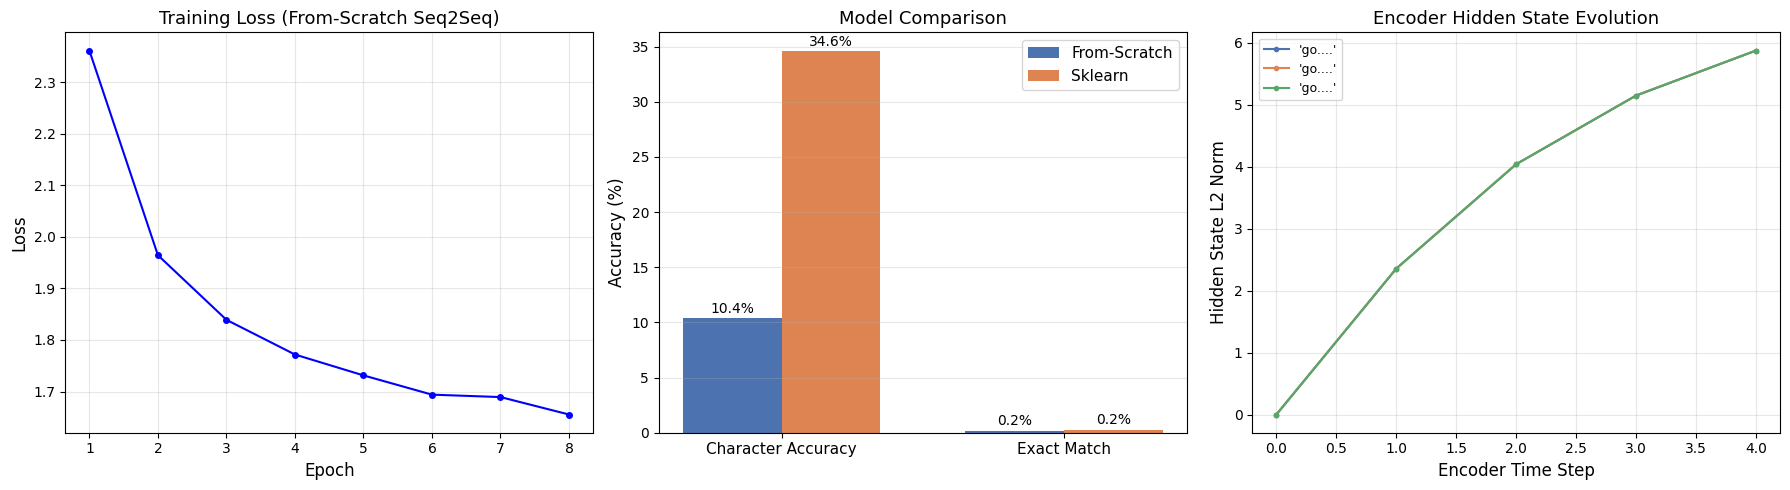

Plots saved as seq2seq_plots.png


In [34]:
# ---- Plot 1: Training Loss ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(range(1, len(loss_hist) + 1), loss_hist, 'b-o', markersize=4)
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].set_title("Training Loss (From-Scratch Seq2Seq)", fontsize=13)
axes[0].grid(alpha=0.3)

# ---- Plot 2: Accuracy comparison ----
metrics = ['Character Accuracy', 'Exact Match']
scratch_scores = [char_acc * 100, exact_acc * 100]
sklearn_scores = [sk_char_acc * 100, sk_exact_acc * 100]

x = np.arange(len(metrics))
width = 0.35
bars1 = axes[1].bar(x - width/2, scratch_scores, width, label='From-Scratch', color='#4C72B0')
bars2 = axes[1].bar(x + width/2, sklearn_scores, width, label='Sklearn', color='#DD8452')
axes[1].set_ylabel("Accuracy (%)", fontsize=12)
axes[1].set_title("Model Comparison", fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3, axis='y')

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{bar.get_height():.1f}%", ha='center', fontsize=10)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{bar.get_height():.1f}%", ha='center', fontsize=10)

# ---- Plot 3: Encoder hidden-state norm evolution ----
n_examples = 3
colors = ['#4C72B0', '#DD8452', '#55A868']

for ex in range(n_examples):
    states = scratch_model._encoder_forward(enc_data[ex])
    norms = [np.linalg.norm(s) for s in states]
    axes[2].plot(range(len(norms)), norms, 'o-', color=colors[ex],
                 markersize=3, label=f"'{pairs[ex][0][:15]}...'")

axes[2].set_xlabel("Encoder Time Step", fontsize=12)
axes[2].set_ylabel("Hidden State L2 Norm", fontsize=12)
axes[2].set_title("Encoder Hidden State Evolution", fontsize=13)
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("seq2seq_plots.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved as seq2seq_plots.png")


## Part 4: Hyperparameter Experiments

Two hyperparameters matter most for our RNN seq2seq:

1. **Hidden size** — controls the capacity of the context vector. Too small = underfit (bottleneck), too large = overfit + slow.
2. **Learning rate** — controls convergence speed. Too high = divergence, too low = slow progress.

We sweep both and plot the effect on final loss.


Running hyperparameter sweep (may take 1-2 minutes)...

  Hidden size 16 — Final loss: 2.0451
  Hidden size 32 — Final loss: 1.8267
  Hidden size 48 — Final loss: 1.7643
  Hidden size 64 — Final loss: 1.7252
  LR 0.001 — Final loss: 2.8797
  LR 0.005 — Final loss: 1.9769
  LR 0.010 — Final loss: 1.8646
  LR 0.050 — Final loss: 2.9728
  LR 0.100 — Final loss: 4.4667


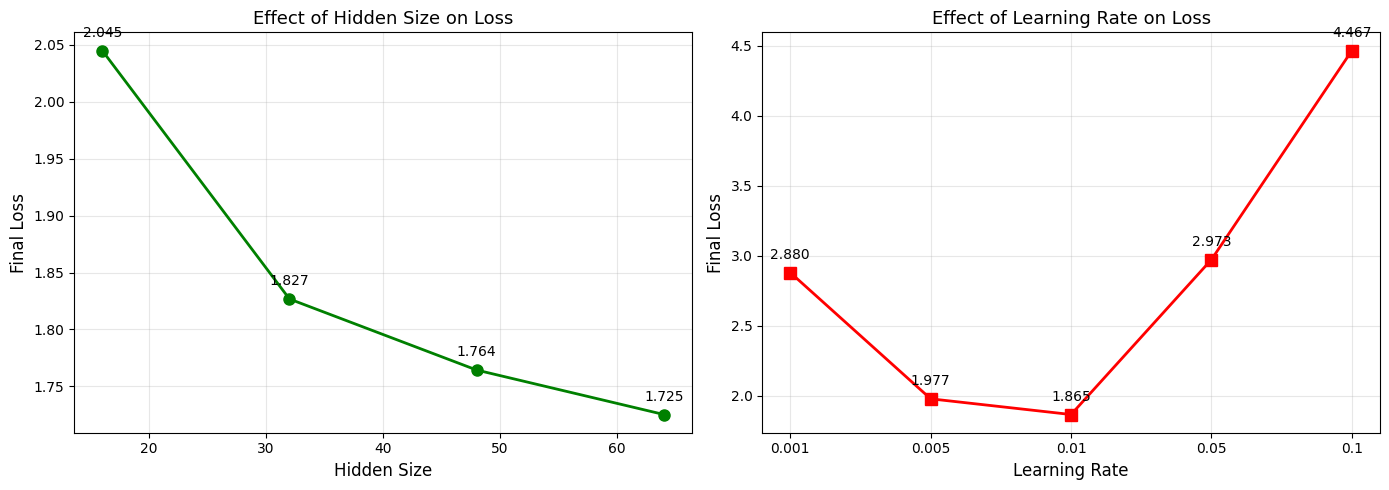


Hyperparameter plots saved as seq2seq_hp_sweep.png


In [35]:
print("Running hyperparameter sweep (may take 1-2 minutes)...\n")

# Use a smaller subset for faster experiments
sweep_size = 500
enc_sweep = enc_data[:sweep_size]
dec_in_sweep = dec_in_data[:sweep_size]
dec_tgt_sweep = dec_tgt_data[:sweep_size]

# ---- Experiment 1: Hidden Size ----
hidden_sizes = [16, 32, 48, 64]
hs_losses = []

for hs in hidden_sizes:
    model = Seq2SeqScratch(
        input_vocab_size=eng_vocab.size,
        output_vocab_size=fra_vocab.size,
        hidden_size=hs, learning_rate=0.01
    )
    hist = model.fit(enc_sweep, dec_in_sweep, dec_tgt_sweep,
                     epochs=5, verbose=False)
    hs_losses.append(hist[-1])
    print(f"  Hidden size {hs:2d} — Final loss: {hist[-1]:.4f}")

# ---- Experiment 2: Learning Rate ----
lrs = [0.001, 0.005, 0.01, 0.05, 0.1]
lr_losses = []

for lr in lrs:
    model = Seq2SeqScratch(
        input_vocab_size=eng_vocab.size,
        output_vocab_size=fra_vocab.size,
        hidden_size=32, learning_rate=lr
    )
    hist = model.fit(enc_sweep, dec_in_sweep, dec_tgt_sweep,
                     epochs=5, verbose=False)
    lr_losses.append(hist[-1])
    print(f"  LR {lr:.3f} — Final loss: {hist[-1]:.4f}")

# ---- Plot results ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hidden size
axes[0].plot(hidden_sizes, hs_losses, 'go-', markersize=8, linewidth=2)
axes[0].set_xlabel("Hidden Size", fontsize=12)
axes[0].set_ylabel("Final Loss", fontsize=12)
axes[0].set_title("Effect of Hidden Size on Loss", fontsize=13)
axes[0].grid(alpha=0.3)
for hs, loss in zip(hidden_sizes, hs_losses):
    axes[0].annotate(f"{loss:.3f}", (hs, loss), textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=10)

# Learning rate
axes[1].plot([str(lr) for lr in lrs], lr_losses, 'rs-', markersize=8, linewidth=2)
axes[1].set_xlabel("Learning Rate", fontsize=12)
axes[1].set_ylabel("Final Loss", fontsize=12)
axes[1].set_title("Effect of Learning Rate on Loss", fontsize=13)
axes[1].grid(alpha=0.3)
for lr, loss in zip(lrs, lr_losses):
    axes[1].annotate(f"{loss:.3f}", (str(lr), loss), textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("seq2seq_hp_sweep.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nHyperparameter plots saved as seq2seq_hp_sweep.png")


## Part 5: Interview Corner

### "Walk me through the forward pass of a seq2seq model during training vs. inference."

**Training:**

1. The encoder receives the *full input sequence* (e.g., "hello<EOS>") one token at a time. At each step, the RNN cell computes `h_t = tanh(W_ih · x_t + W_hh · h_{t-1} + b)`. The final encoder state `h_T` is the *context vector*.
2. The decoder starts with `h_0 = h_T`. At step 1, it receives `<SOS>` as input and produces a logit vector over the output vocabulary. The loss is computed against the first real target token.
3. **Teacher forcing:** at step 2 the decoder receives the *target token*, not its own prediction. This makes training stable and fast. Each step computes cross-entropy loss.
4. Gradients are accumulated via BPTT: we unroll the decoder backwards, then continue through the encoder. Gradients are clipped to prevent explosion.

**Inference (greedy decoding):**

1. Encoder forward pass is identical — it encodes the input into the context vector.
2. Decoder starts with `<SOS>`. It computes logits, softmax, and picks `argmax`.
3. **That predicted token becomes the next input** — no teacher forcing. If the model predicts a wrong token early, errors compound.
4. Generation stops when `<EOS>` is emitted or a max length is reached.

The key conceptual difference: training uses ground truth as input (teacher forcing), inference uses the model's own predictions (autoregressive). This mismatch is called *exposure bias* and is why scheduled sampling or beam search can help.


## Key Takeaways for Interviews

1. **Encoder-decoder = two RNNs:** The encoder compresses the input into a context vector; the decoder expands that vector into an output sequence. The bottleneck is both the core idea and the main weakness (mitigated by attention).
2. **Teacher forcing is a training trick — removed at inference:** During training the decoder gets ground-truth inputs; during inference it gets its own predictions. This discrepancy (exposure bias) is a common failure mode.
3. **BPTT unfolds both RNNs back to front:** Gradients flow from the last decoder step through every decoder and encoder time step. Gradient clipping is essential because repeated tanh multiplications cause vanishing/exploding gradients.
4. **Hidden size controls the bottleneck capacity:** Too small → lossy compression; too large → overfitting and slow training. The context vector must encode the entire input meaning — this is why attention was invented.
5. **Sklearn cannot naturally handle variable-length sequence outputs:** Multi-output classifiers assume fixed-size, position-independent outputs. The seq2seq advantage comes from *sequential dependency modeling*, not just feature extraction.
